In [1]:
# Enable Debugging

%load_ext autoreload
%autoreload 2

In [2]:
#
# Import the campaign diagram class
#
import sys
import os

sys.path.append(os.path.abspath("../../"))
from campaign_diagram import *


In [3]:
# Define tiles for pipeline example

repeat = 4

kernel3a = Kernel(name='EinsumA',
                  start=0,
                  duration=5,
                  compute_util=0.3,
                  bw_util=0.15)


kernel3b = Kernel(name='EinsumB',
                  start=kernel3a.end,
                  duration=10,
                  compute_util=0.2,
                  bw_util=0.6)


kernel3c = Kernel(name='EinsumC',
                  start=kernel3b.end,
                  duration=5,
                  compute_util=0.5,   # was 0.2
                  bw_util=0.25)

original_cascade = Cascade(name="Three-step Cascade",
                           kernels=[kernel3a, kernel3b, kernel3c])



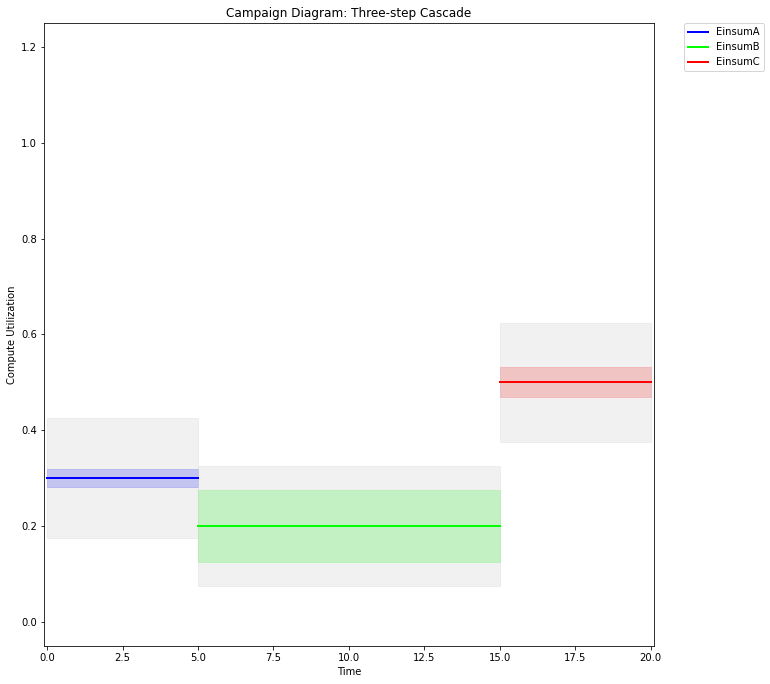

Cascade duration: 20.00
Cascade average compute utilization: 0.30
Cascade average bw utilization: 0.40


In [4]:
CampaignDiagram(original_cascade).draw()

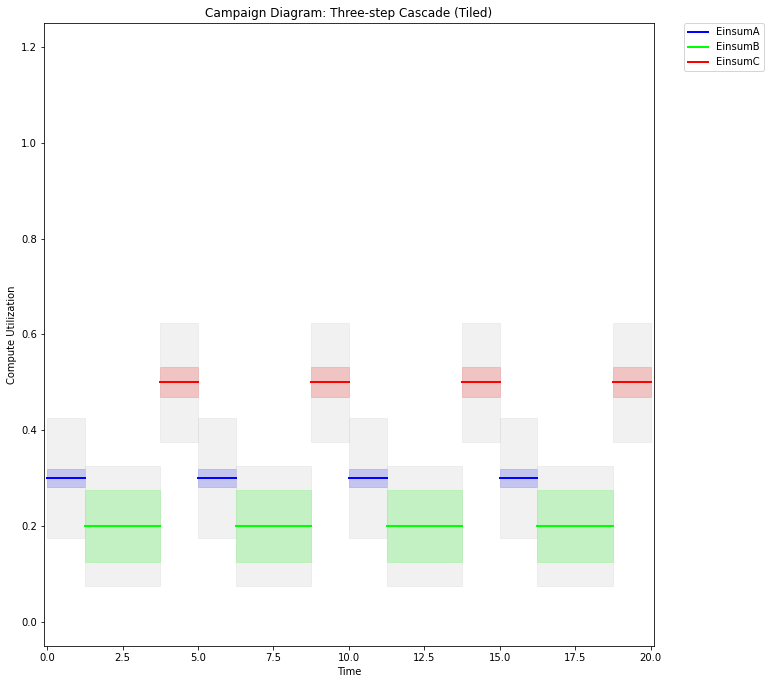

Cascade duration: 20.00
Cascade average compute utilization: 0.30
Cascade average bw utilization: 0.40


In [5]:
# Unpipelined processing

tiled_cascade = original_cascade.tile(repeat)
CampaignDiagram(tiled_cascade).draw()

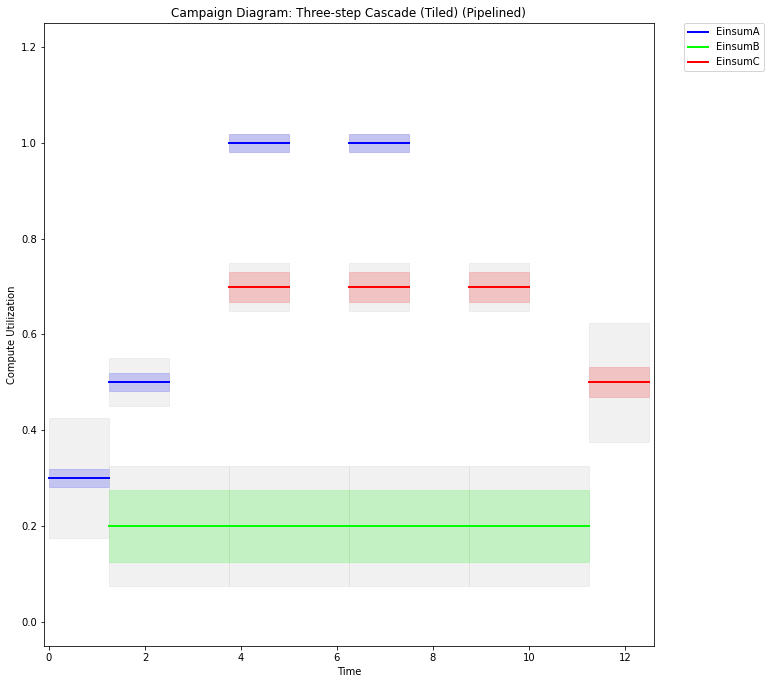

Cascade duration: 12.50
Cascade average compute utilization: 0.48
Cascade average bw utilization: 0.64


In [6]:
# Pipelined diagram (undilated)

pipelined_cascade = tiled_cascade.pipeline(3)

CampaignDiagram(pipelined_cascade).draw()

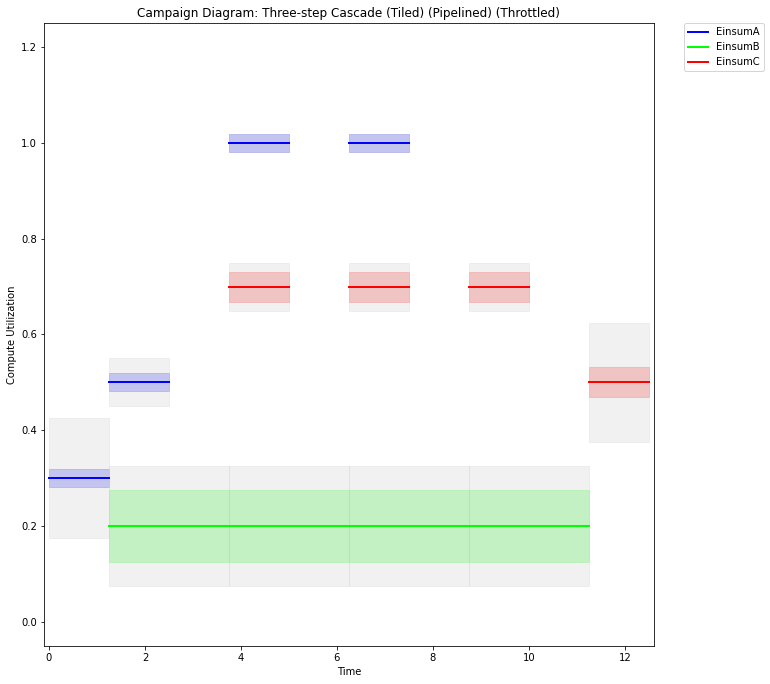

Cascade duration: 12.50
Cascade average compute utilization: 0.48
Cascade average bw utilization: 0.64


In [7]:
throttled_cascade = pipelined_cascade.throttle() 
   
CampaignDiagram(throttled_cascade).draw()

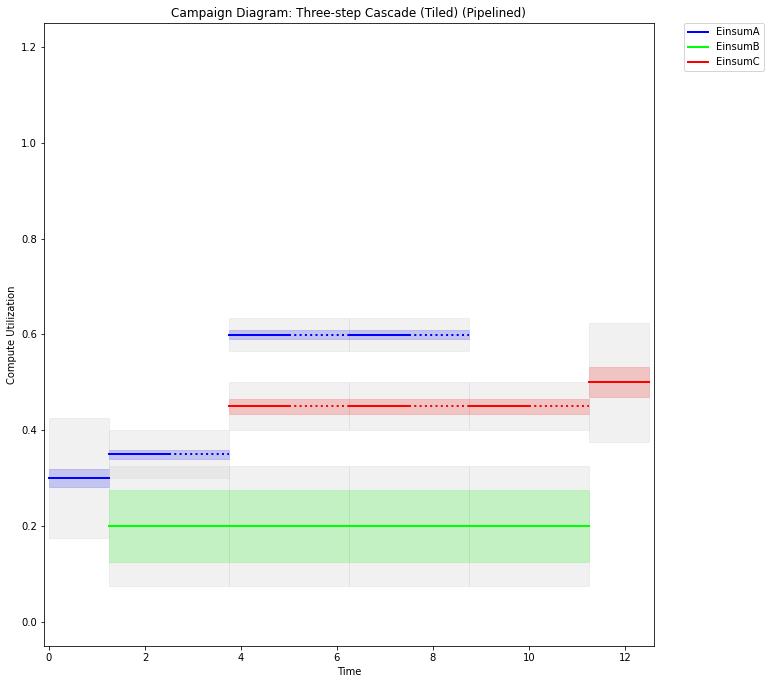

Cascade duration: 12.50
Cascade average compute utilization: 0.48
Cascade average bw utilization: 0.64


In [8]:
# Pipelined diagram (dilated)

pipelined_cascade2 = tiled_cascade.pipeline(stages=3, spread=True)
#print(f"{pipelinedcascade}")
    
CampaignDiagram(pipelined_cascade2).draw()

## Three stage pipeline that needs to be throttled


In [9]:
# Define tiles for pipeline example

repeat = 4

kernel4a = Kernel(name='EinsumA',
                  start=0,
                  duration=5,
                  compute_util=0.2,
                  bw_util=0.8)


kernel4b = Kernel(name='EinsumB',
                  start=kernel4a.end,
                  duration=10,
                  compute_util=0.3,
                  bw_util=0.6)


kernel4c = Kernel(name='EinsumC',
                  start=kernel4b.end,
                  duration=5,
                  compute_util=0.8,   # was 0.2
                  bw_util=0.25)

original_cascade4 = Cascade(name="Overloaded Cascade",
                            kernels=[kernel4a, kernel4b, kernel4c])



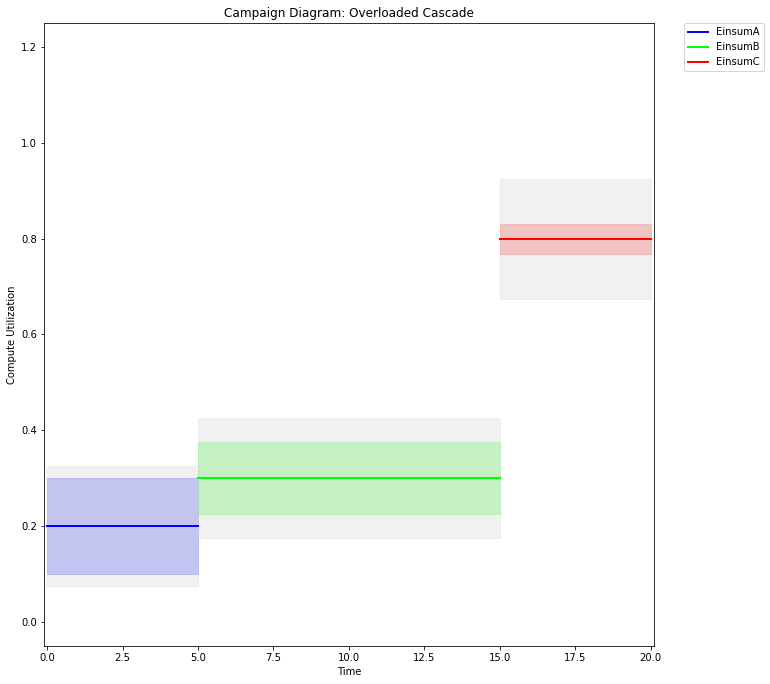

Cascade duration: 20.00
Cascade average compute utilization: 0.40
Cascade average bw utilization: 0.56


In [10]:
CampaignDiagram(original_cascade4).draw()

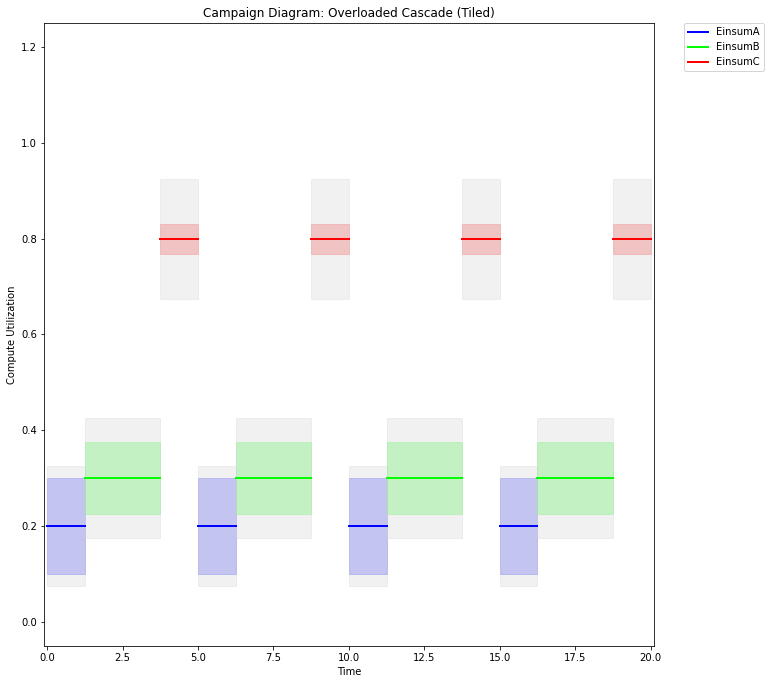

Cascade duration: 20.00
Cascade average compute utilization: 0.40
Cascade average bw utilization: 0.56


In [11]:
# Unpipelined processing

tiled_cascade4 = original_cascade4.tile(repeat)
CampaignDiagram(tiled_cascade4).draw()


1.25: Bandwidth overflow (1.40)
3.75: Bandwidth overflow (1.40)
3.75: Compute Overflow (1.30)
3.75: Bandwidth overflow (1.25)
6.25: Bandwidth overflow (1.40)
6.25: Compute Overflow (1.30)
6.25: Bandwidth overflow (1.25)
8.75: Compute Overflow (1.10)


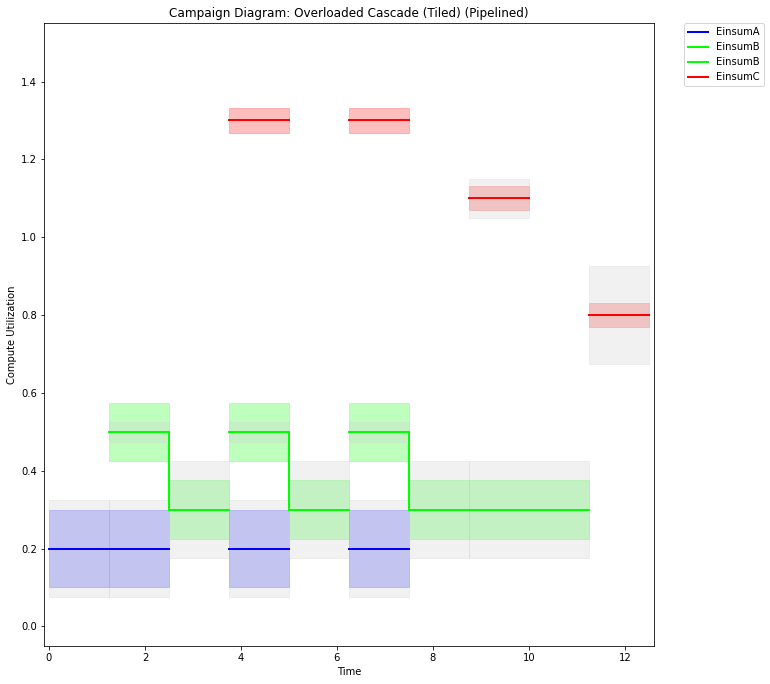

Cascade duration: 12.50
Cascade average compute utilization: 0.64
Cascade average bw utilization: 0.90


In [12]:
# Pipelined diagram (undilated)

pipelined_cascade4 = tiled_cascade4.pipeline(3)

CampaignDiagram(pipelined_cascade4).draw()

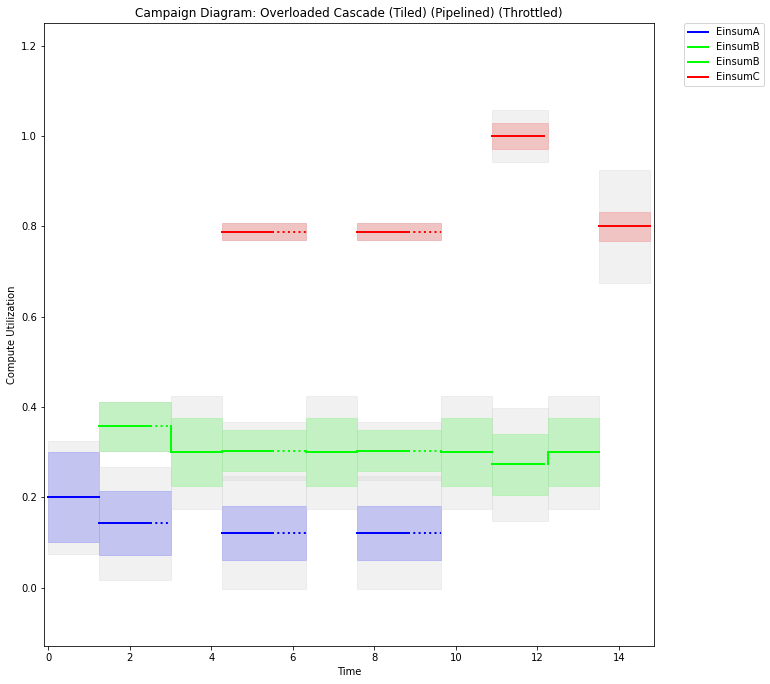

Cascade duration: 14.75
Cascade average compute utilization: 0.54
Cascade average bw utilization: 0.76


In [13]:
CampaignDiagram(pipelined_cascade4.throttle()).draw()


3.75: Bandwidth overflow (1.12)
6.25: Bandwidth overflow (1.12)


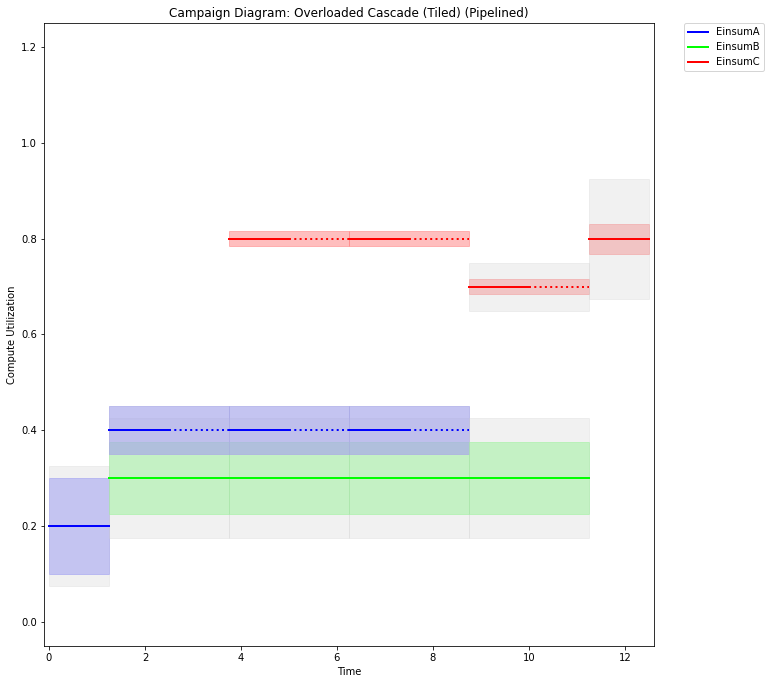

Cascade duration: 12.50
Cascade average compute utilization: 0.64
Cascade average bw utilization: 0.90


In [14]:
# Pipelined diagram (dilated)

pipelined_cascade5 = tiled_cascade4.pipeline(3, spread=True)

CampaignDiagram(pipelined_cascade5).draw()

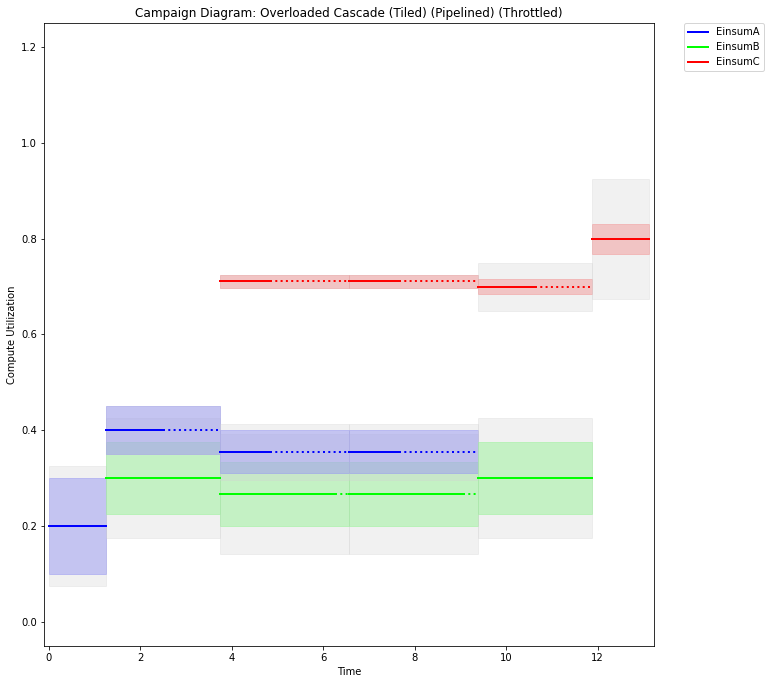

Cascade duration: 13.12
Cascade average compute utilization: 0.61
Cascade average bw utilization: 0.86


In [15]:
CampaignDiagram(pipelined_cascade5.throttle()).draw()